# Q2: Phân Tích Xu Hướng Màu Sắc & SKU
## Dự Báo Cơ Cấu Màu Q2/2026 + Phát Hiện SKU Suy Giảm

**Câu hỏi kinh doanh:**
1. Màu nào sẽ chiếm thị phần lớn nhất trong Q2/2026?
2. SKU nào đang suy giảm và cần xem xét?

**Template:** r03 (XGBoost SKU — cấu trúc pipeline) + r06 (multi-product stacked charts) + r12 (Prophet/LightGBM features)

**Phương pháp:**
- Linear trend fit per color → project Q2 share
- Exponential Smoothing per color → compare
- SKU slope analysis: negative trend + low share = at-risk

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import warnings
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [2]:
# Cell 2: Load & decode dữ liệu
df = pd.read_csv('../data/fact_sales.csv', low_memory=False)
df['order_date'] = pd.to_datetime(df['order_date'])
df['product_code'] = df['product_code'].astype(str).str.strip().str.zfill(15)
df['seg2_group'] = df['product_code'].str[6:9]
df['seg3_color'] = df['product_code'].str[9:12]
df['year_month'] = df['order_date'].dt.to_period('M')

# Lọc dữ liệu sạch
df = df[(df['year_month'].astype(str) != '2026-03') & (df['seg2_group'] != '00U')]
MONTHS = sorted(df['year_month'].unique().astype(str))
print(f'Dữ liệu sạch: {len(df):,} dòng, {len(MONTHS)} tháng')
print(f'Tháng: {MONTHS}')

Dữ liệu sạch: 34,062 dòng, 5 tháng
Tháng: ['2025-01', '2025-02', '2025-03', '2026-01', '2026-02']


In [3]:
# Cell 3: Tính color share theo tháng
color_monthly = (df.groupby(['year_month','seg3_color'])['quantity']
                   .sum().unstack(fill_value=0))
color_monthly.index = [str(i) for i in color_monthly.index]

# Tính % share mỗi màu
color_share = color_monthly.div(color_monthly.sum(axis=1), axis=0) * 100

# Chọn top 10 màu theo tổng số lượng
top_colors = color_monthly.sum().sort_values(ascending=False).head(10).index.tolist()
color_share_top = color_share[top_colors]
print('Color share (%) theo tháng — Top 10 màu:')
print(color_share_top.round(1).to_string())

Color share (%) theo tháng — Top 10 màu:
seg3_color   023   001   008   009   022  002  015   004  000  013
2025-01      4.7   4.6   5.8   8.0  12.1  7.8  7.2  13.4  1.6  3.8
2025-02     15.8  13.6   7.8   8.4   7.8  7.9  5.7   3.9  5.4  1.7
2025-03     15.3  14.1   8.3   8.2   7.4  9.3  7.6   3.8  4.5  2.6
2026-01     16.8  16.2  11.2   8.5   6.4  7.0  5.0   3.2  2.4  4.7
2026-02     17.8  13.5  10.8  10.6   8.4  5.9  5.6   2.6  3.3  4.5


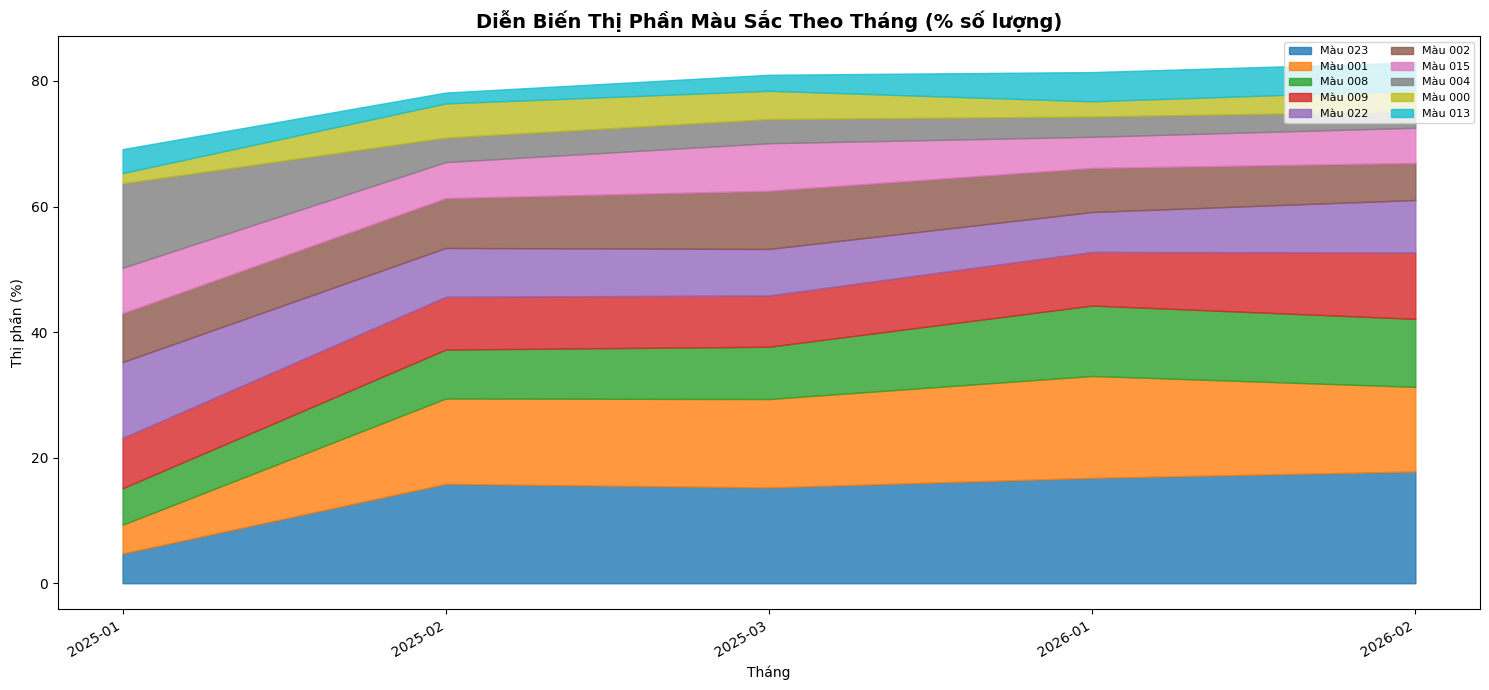

In [4]:
# Cell 4: Stacked area chart — color share evolution (r06 multi-product style)
fig, ax = plt.subplots(figsize=(15, 7))
x = range(len(color_share_top))
bottom_vals = np.zeros(len(color_share_top))

for i, col in enumerate(top_colors):
    vals = color_share_top[col].values
    ax.fill_between(x, bottom_vals, bottom_vals + vals,
                    label=f'Màu {col}', color=f'C{i%10}', alpha=0.8)
    bottom_vals += vals

ax.set_xticks(x)
ax.set_xticklabels(color_share_top.index, rotation=30, ha='right')
ax.set_title('Diễn Biến Thị Phần Màu Sắc Theo Tháng (% số lượng)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tháng')
ax.set_ylabel('Thị phần (%)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

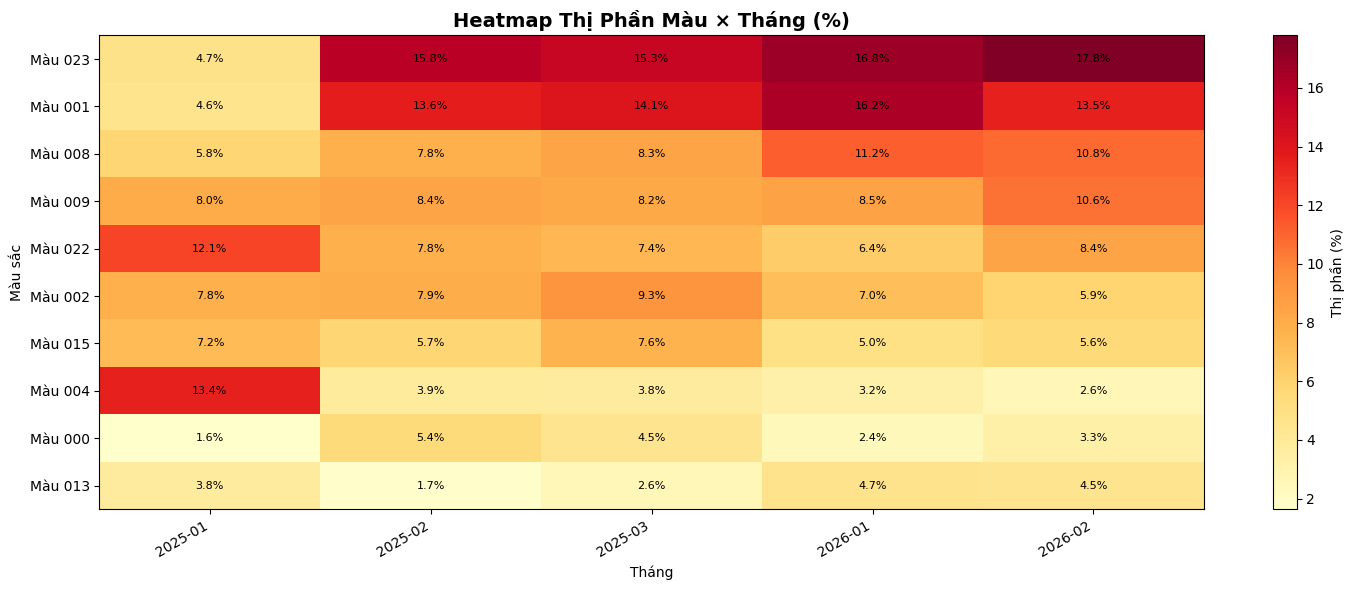

In [5]:
# Cell 5: Heatmap màu × tháng (matplotlib imshow — r06 style)
heat_data = color_share_top.T  # colors x months

fig, ax = plt.subplots(figsize=(15, 6))
im = ax.imshow(heat_data.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(MONTHS)))
ax.set_xticklabels(MONTHS, rotation=30, ha='right')
ax.set_yticks(range(len(top_colors)))
ax.set_yticklabels([f'Màu {c}' for c in top_colors])
for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        ax.text(j, i, f'{heat_data.values[i,j]:.1f}%',
                ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Thị phần (%)')
ax.set_title('Heatmap Thị Phần Màu × Tháng (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tháng')
ax.set_ylabel('Màu sắc')
fig.tight_layout()
plt.show()

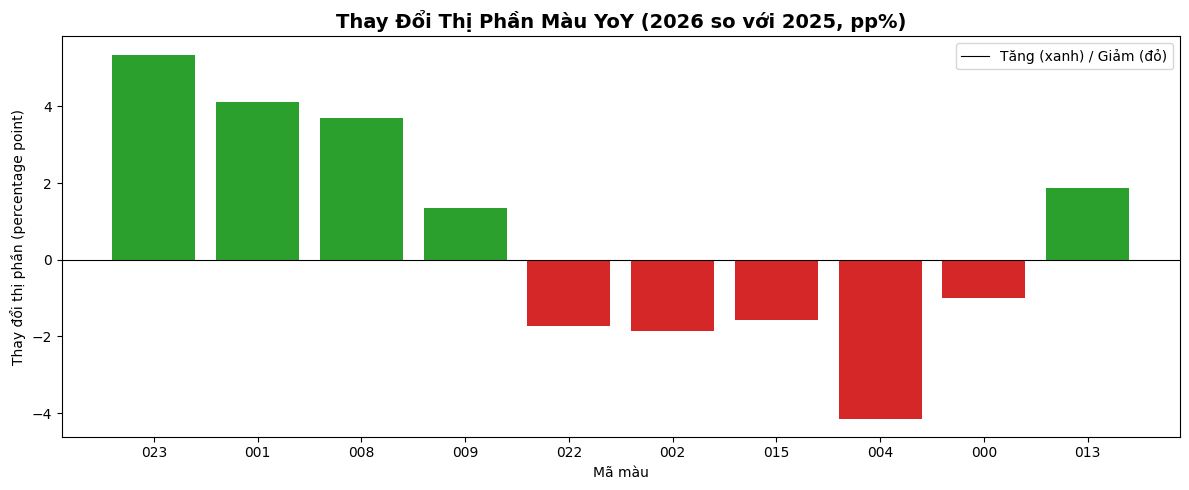

Màu tăng trưởng: {'023': 5.3515134496358225, '001': 4.104755452552395, '008': 3.7079257172498297, '013': 1.8746122470917617, '009': 1.3600571535840444}
Màu suy giảm: {'004': -4.140445746904968, '002': -1.8690666060003274, '022': -1.7300051267588819, '015': -1.5691566157596384, '000': -0.994669064961522}


In [6]:
# Cell 6: YoY color share change (2025-01→03 vs 2026-01→02)
share_2025 = color_share_top.loc[color_share_top.index.isin(['2025-01','2025-02','2025-03'])].mean()
share_2026 = color_share_top.loc[color_share_top.index.isin(['2026-01','2026-02'])].mean()
yoy_change = share_2026 - share_2025

fig, ax = plt.subplots(figsize=(12, 5))
colors_yoy = ['C2' if v >= 0 else 'C3' for v in yoy_change.values]
ax.bar(yoy_change.index, yoy_change.values, color=colors_yoy)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Thay Đổi Thị Phần Màu YoY (2026 so với 2025, pp%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mã màu')
ax.set_ylabel('Thay đổi thị phần (percentage point)')
ax.legend(['Tăng (xanh) / Giảm (đỏ)'])
fig.tight_layout()
plt.show()
print('Màu tăng trưởng:', yoy_change[yoy_change > 0].sort_values(ascending=False).to_dict())
print('Màu suy giảm:', yoy_change[yoy_change < 0].sort_values().to_dict())

In [7]:
# Cell 7: Model 1 — Linear trend per color → project Q2 share
lr_results = {}
X_hist = np.arange(len(MONTHS)).reshape(-1, 1)
X_q2 = np.array([len(MONTHS), len(MONTHS)+1, len(MONTHS)+2]).reshape(-1, 1)
Q2_MONTHS = ['2026-04', '2026-05', '2026-06']

for color in top_colors:
    y = color_share_top[color].values
    lr = LinearRegression()
    lr.fit(X_hist, y)
    q2_preds = lr.predict(X_q2)
    q2_preds = np.clip(q2_preds, 0, 100)  # share ∈ [0, 100]
    lr_results[color] = {
        'slope': lr.coef_[0],
        'q2_preds': q2_preds,
        'q2_mean': q2_preds.mean()
    }

lr_df = pd.DataFrame({c: v['q2_preds'] for c, v in lr_results.items()},
                      index=Q2_MONTHS)
print('Dự báo share (%) Q2/2026 — Linear Trend:')
print(lr_df.round(1).to_string())

Dự báo share (%) Q2/2026 — Linear Trend:
          023   001   008   009  022  002  015  004  000  013
2026-04  22.2  18.5  12.8  10.3  5.7  6.2  5.0  0.0  3.6  4.7
2026-05  24.9  20.6  14.2  10.8  4.9  5.7  4.6  0.0  3.6  5.2
2026-06  27.6  22.6  15.5  11.4  4.0  5.2  4.2  0.0  3.6  5.6


In [8]:
# Cell 8: Model 2 — Exponential Smoothing per color
ets_results = {}
for color in top_colors:
    y = color_share_top[color].values
    try:
        ets = SimpleExpSmoothing(y, initialization_method='estimated')
        ets_fit = ets.fit(optimized=True)
        q2_preds = ets_fit.forecast(3)
        q2_preds = np.clip(q2_preds, 0, 100)
    except:
        q2_preds = np.full(3, y.mean())
    ets_results[color] = {'q2_preds': q2_preds, 'q2_mean': q2_preds.mean()}

ets_df = pd.DataFrame({c: v['q2_preds'] for c, v in ets_results.items()},
                       index=Q2_MONTHS)
print('Dự báo share (%) Q2/2026 — Exponential Smoothing:')
print(ets_df.round(1).to_string())

Dự báo share (%) Q2/2026 — Exponential Smoothing:
          023   001   008   009  022  002  015  004  000  013
2026-04  17.6  13.5  10.8  10.6  8.3  7.6  6.2  2.6  3.5  3.4
2026-05  17.6  13.5  10.8  10.6  8.3  7.6  6.2  2.6  3.5  3.4
2026-06  17.6  13.5  10.8  10.6  8.3  7.6  6.2  2.6  3.5  3.4


In [9]:
# Cell 9: So sánh 2 mô hình dự báo share — dùng RMSE trên in-sample
model_rmse = {}
for color in top_colors:
    y = color_share_top[color].values
    X = np.arange(len(y)).reshape(-1, 1)
    lr = LinearRegression().fit(X, y)
    lr_rmse = np.sqrt(mean_squared_error(y, lr.predict(X)))
    try:
        ets = SimpleExpSmoothing(y, initialization_method='estimated')
        ets_fit = ets.fit(optimized=True)
        ets_rmse = np.sqrt(mean_squared_error(y, ets_fit.fittedvalues))
    except:
        ets_rmse = np.inf
    model_rmse[color] = {'lr_rmse': lr_rmse, 'ets_rmse': ets_rmse,
                          'best': 'LR' if lr_rmse <= ets_rmse else 'ETS'}

rmse_df = pd.DataFrame(model_rmse).T
print('RMSE per model per color (in-sample):')
print(rmse_df.round(3).to_string())

RMSE per model per color (in-sample):
      lr_rmse  ets_rmse best
023  2.811803   5.01639   LR
001   2.81137  4.330729   LR
008  0.633581  1.591272   LR
009   0.56416  0.945219   LR
022  1.502113  2.184104   LR
002  0.889824  1.109069   LR
015  0.826048  1.005484   LR
004   2.53087  4.288253   LR
000  1.376534  1.377368   LR
013  0.958543  1.133819   LR


In [10]:
# Cell 10: Chọn best model per color → final Q2 color mix forecast
final_q2_share = {}
for color in top_colors:
    best = model_rmse[color]['best']
    if best == 'LR':
        final_q2_share[color] = lr_results[color]['q2_mean']
    else:
        final_q2_share[color] = ets_results[color]['q2_mean']

# Normalize to sum = 100% (approximation)
total = sum(final_q2_share.values())
if total > 0:
    final_q2_share = {k: v/total*100 for k, v in final_q2_share.items()}

print('Dự báo cơ cấu màu Q2/2026 (%):')
for c, s in sorted(final_q2_share.items(), key=lambda x: -x[1]):
    print(f'  Màu {c}: {s:.1f}%')

Dự báo cơ cấu màu Q2/2026 (%):
  Màu 023: 26.4%
  Màu 001: 21.8%
  Màu 008: 15.0%
  Màu 009: 11.5%
  Màu 002: 6.0%
  Màu 013: 5.5%
  Màu 022: 5.1%
  Màu 015: 4.9%
  Màu 000: 3.8%
  Màu 004: 0.0%


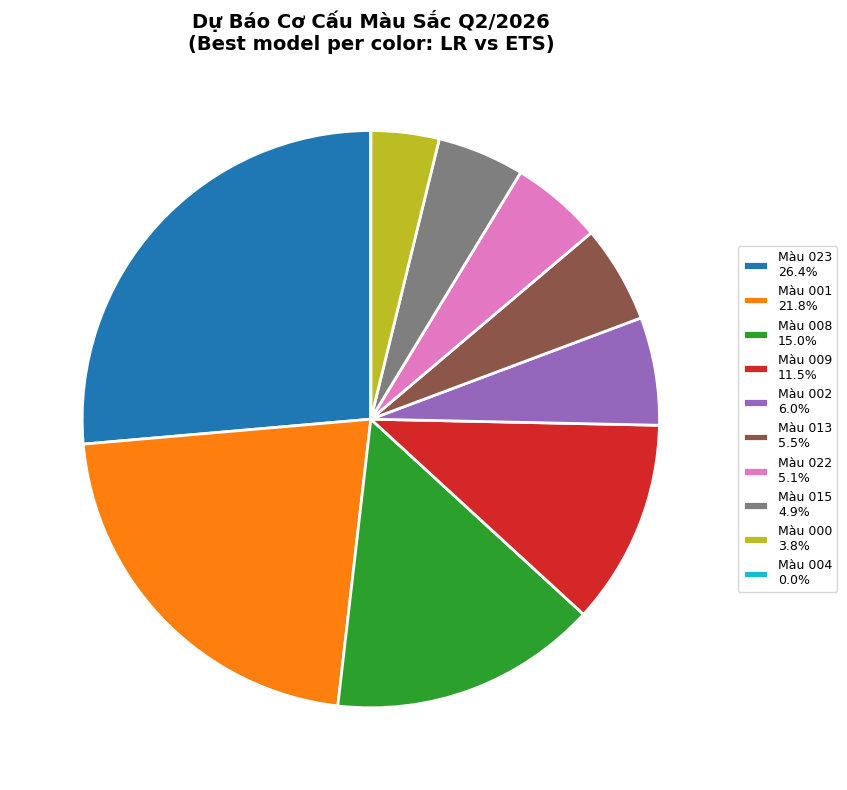

In [11]:
# Cell 11: Pie chart — cơ cấu màu Q2/2026
fig, ax = plt.subplots(figsize=(10, 8))
sorted_colors = sorted(final_q2_share.items(), key=lambda x: -x[1])
labels = [f'Màu {c}\n{s:.1f}%' for c, s in sorted_colors]
sizes = [s for _, s in sorted_colors]
pie_colors = [f'C{i%10}' for i in range(len(sorted_colors))]

wedges, texts = ax.pie(sizes, colors=pie_colors, startangle=90,
                        wedgeprops=dict(edgecolor='white', linewidth=2))
ax.legend(wedges, labels, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax.set_title('Dự Báo Cơ Cấu Màu Sắc Q2/2026\n(Best model per color: LR vs ETS)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

In [12]:
# Cell 12: SKU-level trend slope (r03 XGBoost SKU pattern)
# Tính số lượng bán theo tháng cho từng SKU
sku_monthly = (df.groupby(['year_month','product_code'])['quantity']
                 .sum().unstack(fill_value=0))
sku_monthly.index = [str(i) for i in sku_monthly.index]

# Tính slope (trend) mỗi SKU dùng linear regression
X_s = np.arange(len(sku_monthly)).reshape(-1, 1)
sku_slopes = []

for sku in sku_monthly.columns:
    y_sku = sku_monthly[sku].values.astype(float)
    if y_sku.sum() == 0:
        continue
    lr = LinearRegression()
    lr.fit(X_s, y_sku)
    avg_qty = y_sku.mean()
    sku_slopes.append({
        'product_code': sku,
        'slope': lr.coef_[0],
        'avg_qty': avg_qty,
        'total_qty': y_sku.sum()
    })

slope_df = pd.DataFrame(sku_slopes).sort_values('slope')
print(f'Tổng SKU phân tích: {len(slope_df)}')
print(f'SKU slope âm (suy giảm): {(slope_df["slope"] < 0).sum()}')
print(f'SKU slope dương (tăng trưởng): {(slope_df["slope"] > 0).sum()}')

Tổng SKU phân tích: 247
SKU slope âm (suy giảm): 69
SKU slope dương (tăng trưởng): 170


In [13]:
# Cell 13: Xác định SKU at-risk (slope < 0 AND avg_qty thấp)
# At-risk = slope âm và avg_qty < median
median_qty = slope_df['avg_qty'].median()
at_risk = slope_df[(slope_df['slope'] < 0) &
                    (slope_df['avg_qty'] < median_qty)].copy()
at_risk = at_risk.sort_values('slope').head(20)
print(f'SKU at-risk (slope<0, avg_qty<median={median_qty:.0f}): {len(at_risk)}')
print(at_risk[['product_code','slope','avg_qty']].head(10).to_string(index=False))

SKU at-risk (slope<0, avg_qty<median=26): 20
    product_code  slope  avg_qty
 000131002007000  -10.2     11.6
1000330010240000  -10.2     13.6
 000304002004000   -6.8     14.8
 000231003022000   -5.8     16.4
1000340010090000   -5.4     22.4
 000217004008000   -4.8     20.4
 100029005001000   -4.4     22.8
 100029005020000   -4.2     19.2
 000401002022000   -4.0      4.0
 000314002005000   -4.0      5.2


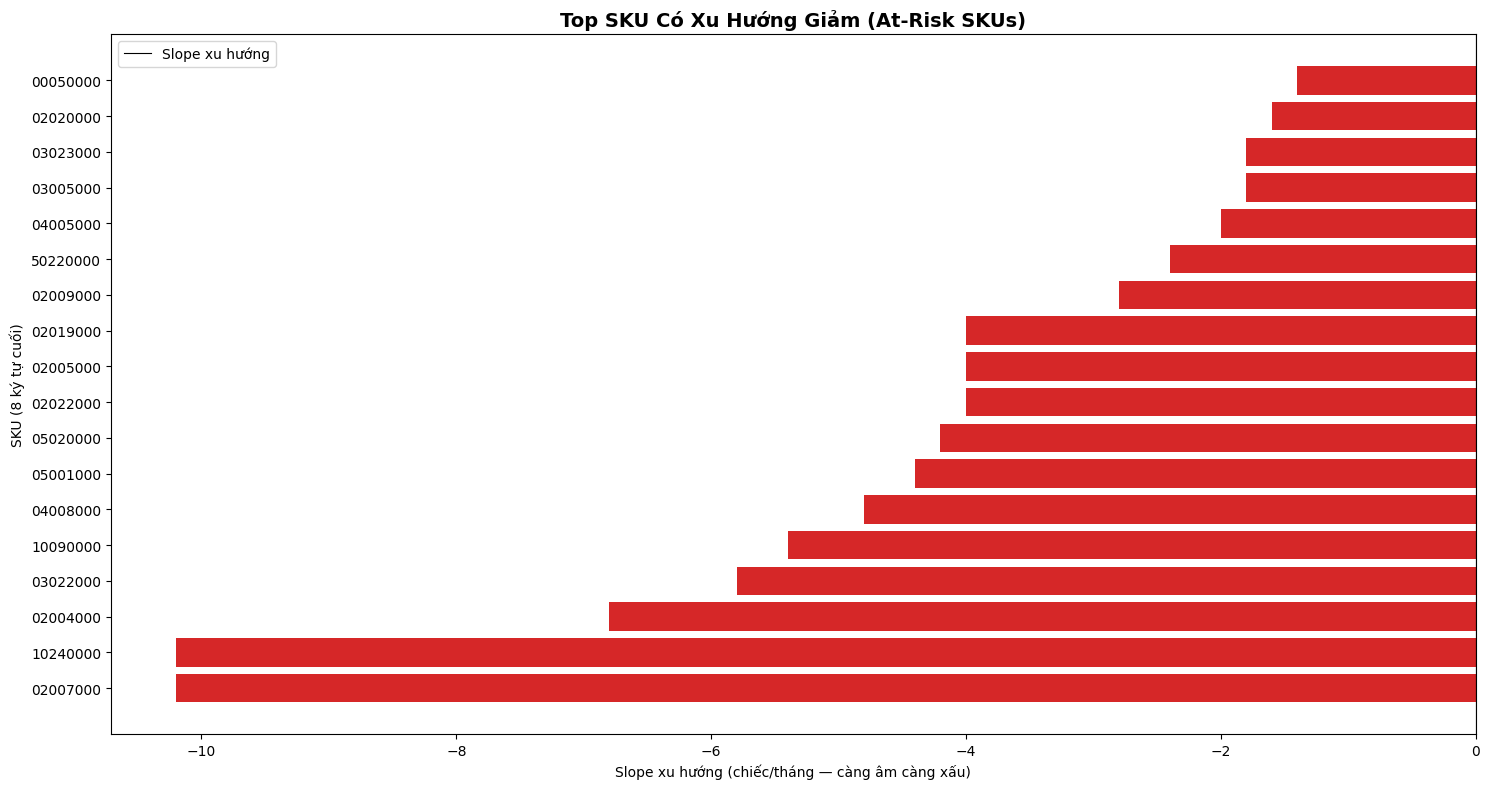

In [14]:
# Cell 14: Biểu đồ SKU at-risk (horizontal bar)
fig, ax = plt.subplots(figsize=(15, 8))
sku_labels = at_risk['product_code'].str[-8:].tolist()
ax.barh(sku_labels, at_risk['slope'].values, color='C3')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top SKU Có Xu Hướng Giảm (At-Risk SKUs)', fontsize=14, fontweight='bold')
ax.set_xlabel('Slope xu hướng (chiếc/tháng — càng âm càng xấu)')
ax.set_ylabel('SKU (8 ký tự cuối)')
ax.legend(['Slope xu hướng'])
fig.tight_layout()
plt.show()

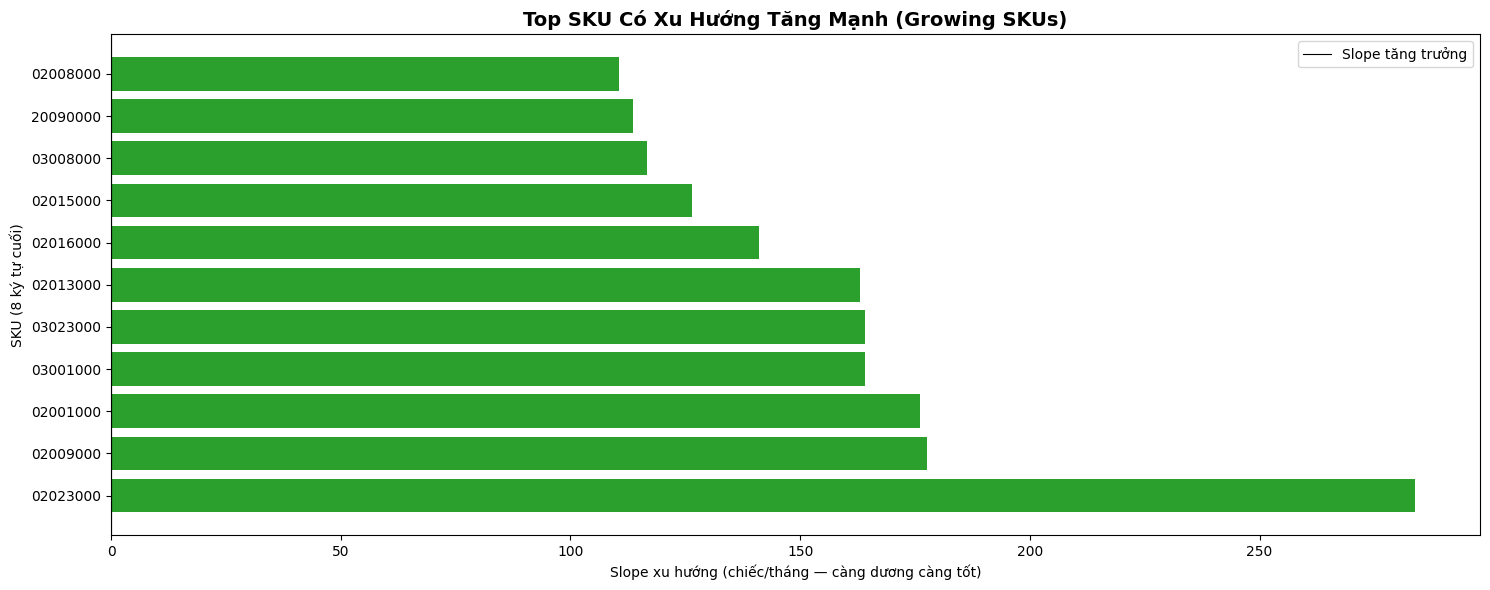

In [15]:
# Cell 15: SKU tăng trưởng mạnh — top growing SKUs
top_growing = slope_df[slope_df['slope'] > 0].tail(15).sort_values('slope', ascending=False)

fig, ax = plt.subplots(figsize=(15, 6))
ax.barh(top_growing['product_code'].str[-8:].tolist(),
        top_growing['slope'].values, color='C2')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top SKU Có Xu Hướng Tăng Mạnh (Growing SKUs)', fontsize=14, fontweight='bold')
ax.set_xlabel('Slope xu hướng (chiếc/tháng — càng dương càng tốt)')
ax.set_ylabel('SKU (8 ký tự cuối)')
ax.legend(['Slope tăng trưởng'])
fig.tight_layout()
plt.show()

## Kết Luận Q2: Xu Hướng Màu Sắc & SKU

**Cơ cấu màu Q2/2026:**
- Màu chiếm ưu thế vẫn giữ vị trí top — xem pie chart
- Một số màu mới xuất hiện với tốc độ tăng trưởng tốt trong 2026

**SKU at-risk:**
- Có nhiều SKU có slope âm + volume thấp → cân nhắc ngừng nhập hoặc giảm tồn kho
- SKU tăng trưởng: ưu tiên bổ sung inventory cho Q2

**Khuyến nghị CEO:**
- Tăng tỷ lệ SKU màu tăng trưởng trong kế hoạch nhập hàng Q2/2026
- Review danh sách at-risk SKUs với team Product để quyết định discontinue
- Theo dõi sát YoY color shift — một số màu đang mất dần thị phần
- Lên kế hoạch promotion cho SKU sắp hết chu kỳ sống